In [16]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"  # Make both GPUs visible
# import os
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:true"
import os
os.environ["HF_HOME"] = "/home/shared/huggingface"
print(os.getenv("HF_HOME"))

/home/shared/huggingface


In [17]:
import torch
print(torch.cuda.is_available())  # Should return True if GPU is available
print(torch.cuda.device_count())  # Number of GPUs available

True
2


In [18]:
import numpy as np
print(np.__version__)

1.26.4


In [19]:
import pandas as pd
import json
import random
from typing import List, Dict, Tuple
import numpy as np
from sklearn.utils import shuffle
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
import time
import csv
from sentence_transformers import SentenceTransformer

# FEW-SHOT EXAMPLE BY EMBEDDING

## Utilities

In [20]:
def read_jsonl(path):
    arr = []
    with open(path, "r", encoding="utf-8") as f:
        for ln in f:
            if ln.strip():
                arr.append(json.loads(ln))
    return arr

def write_jsonl(objs, outpath):
    with open(outpath, "w", encoding="utf-8") as f:
        for o in objs:
            f.write(json.dumps(o, ensure_ascii=False) + "\n")

def read_csv_rows(path, text_col="preprocessed", label_col="compact_label", id_col="id"):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows.append({
                "id": r.get(id_col, ""),
                "text": r.get(text_col, "").strip(),
                "label": r.get(label_col, "").strip()
            })
    return rows

## GET_EXAMPLE_BY_EMBEDDING

In [21]:
from sentence_transformers import SentenceTransformer, SimilarityFunction
import pandas as pd
import json
import os
import numpy as np

def get_example_bert(test_file: str = 'resource/Datasets/Prn/test_scenario3.csv',
                     train_file: str = 'resource/Datasets/Prn/train_scenario3.csv',
                     num_of_example: int = 5,
                     output_file: str =  'resource/Inference Results/Prn/DeepSeek LLM 7b Chat/test_with_example_bert.jsonl',
                     bert_model: str = "indobenchmark/indobert-large-p2",
                     sim_function: str = "cosine",
                     drop_duplicate_text: bool = True):
    """
    Generate few-shot examples using BERT-based semantic similarity (optimized batch processing).

    Args:
        test_file: Path to test CSV file
        train_file: Path to train CSV file
        num_of_example: Number of examples to select for each label
        output_file: Path to output JSONL file
        bert_model: SentenceTransformer model name (default: "all-MiniLM-L6-v2")
        sim_function: Similarity function ('cosine', 'dot', 'euclidean', 'manhattan')
        drop_duplicate_text: Whether to drop duplicate texts from examples
    """
    # Load datasets
    test_df = pd.read_csv(test_file)
    train_df = pd.read_csv(train_file)

    # Filter train data based on labels
    non_porno = train_df[train_df['labels'] == 'non_porno_non_prostitusi'].reset_index(drop=True)
    porno = train_df[train_df['labels'] == 'konten_porno_prostitusi'].reset_index(drop=True)

    # Drop duplicates if requested
    if drop_duplicate_text:
        non_porno = non_porno.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
        porno = porno.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)

    # Ensure enough samples exist
    if len(non_porno) < num_of_example or len(porno) < num_of_example:
        raise ValueError("Not enough examples in train dataset for the given labels")

    # Initialize model
    print(f"Loading BERT model: {bert_model}")
    if sim_function == "cosine":
        model = SentenceTransformer(bert_model, similarity_fn_name=SimilarityFunction.COSINE)
    elif sim_function == "dot":
        model = SentenceTransformer(bert_model, similarity_fn_name=SimilarityFunction.DOT_PRODUCT)
    elif sim_function == "euclidean":
        model = SentenceTransformer(bert_model, similarity_fn_name=SimilarityFunction.EUCLIDEAN)
    elif sim_function == "manhattan":
        model = SentenceTransformer(bert_model, similarity_fn_name=SimilarityFunction.MANHATTAN)
    else:
        raise ValueError("Wrong 'sim_function' parameter. Only 'cosine', 'dot', 'euclidean', or 'manhattan' is allowed.")

    # BATCH ENCODE ALL TEXTS ONCE
    print(f"Encoding {len(test_df)} test instances...")
    test_embeddings = model.encode(test_df['text'].tolist(), show_progress_bar=True)

    print(f"Encoding {len(non_porno)} non-porno examples...")
    non_porno_embeddings = model.encode(non_porno['text'].tolist(), show_progress_bar=True)

    print(f"Encoding {len(porno)} porno examples...")
    porno_embeddings = model.encode(porno['text'].tolist(), show_progress_bar=True)

    # COMPUTE ALL SIMILARITIES IN BATCH
    print("Computing similarity scores...")
    # Similarities shape: (num_test_instances, num_train_examples)
    non_porno_similarities = model.similarity(test_embeddings, non_porno_embeddings).cpu().numpy()
    porno_similarities = model.similarity(test_embeddings, porno_embeddings).cpu().numpy()

    # Ensure the output directory exists
    os.makedirs(os.path.dirname(output_file), exist_ok=True)

    print(f"Generating examples for {len(test_df)} test instances...")

    # Process each test instance
    with open(output_file, 'w') as f:
        for idx, row in test_df.iterrows():
            # Get similarity scores for this instance
            non_porno_sims = non_porno_similarities[idx]
            porno_sims = porno_similarities[idx]

            # Get top N indices based on similarity
            # For cosine/dot: higher is better, for euclidean/manhattan: lower is better
            if sim_function in ["cosine", "dot"]:
                top_non_porno_indices = np.argsort(non_porno_sims)[-num_of_example:][::-1]
                top_porno_indices = np.argsort(porno_sims)[-num_of_example:][::-1]
            else:  # euclidean, manhattan
                top_non_porno_indices = np.argsort(non_porno_sims)[:num_of_example]
                top_porno_indices = np.argsort(porno_sims)[:num_of_example]

            # Extract examples
            bert_ex_porn_0 = [
                (non_porno['text'].iloc[i], non_porno['labels'].iloc[i])
                for i in top_non_porno_indices
            ]

            bert_ex_porn_1 = [
                (porno['text'].iloc[i], porno['labels'].iloc[i])
                for i in top_porno_indices
            ]

            # Create output dictionary
            output = {
                'idx': int(idx),
                'text': row['text'],
                'label': row['labels'],
                'bert_ex_porn_0': bert_ex_porn_0,
                'bert_ex_porn_1': bert_ex_porn_1
            }

            # Write to file
            f.write(json.dumps(output) + '\n')

            # Progress indicator
            if (idx + 1) % 100 == 0:
                print(f"Processed {idx + 1}/{len(test_df)} instances")

    print(f"✓ Examples generated and saved to: {output_file}")

In [42]:
%%time

llm_model = "SahabatAI"
sim_function = "dot"  # Define it once
out = get_example_bert(
    test_file='/home/alvaro_luqman/resource/Datasets/Prn/test_scenario3.csv',
    train_file='/home/alvaro_luqman/resource/Datasets/Prn/train_scenario3.csv',
    num_of_example=5,
    output_file=f'/home/alvaro_luqman/resource/Inference Results/Prn/{llm_model}/{sim_function}/test_with_example_bert.jsonl',
    bert_model="indobenchmark/indobert-large-p2",
    sim_function=sim_function,  # Use the same variable
    drop_duplicate_text=True
)

Loading BERT model: indobenchmark/indobert-large-p2


No sentence-transformers model found with name indobenchmark/indobert-large-p2. Creating a new one with mean pooling.


Encoding 2044 test instances...


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Encoding 1184 non-porno examples...


Batches:   0%|          | 0/37 [00:00<?, ?it/s]

Encoding 4814 porno examples...


Batches:   0%|          | 0/151 [00:00<?, ?it/s]

Computing similarity scores...
Generating examples for 2044 test instances...
Processed 100/2044 instances
Processed 200/2044 instances
Processed 300/2044 instances
Processed 400/2044 instances
Processed 500/2044 instances
Processed 600/2044 instances
Processed 700/2044 instances
Processed 800/2044 instances
Processed 900/2044 instances
Processed 1000/2044 instances
Processed 1100/2044 instances
Processed 1200/2044 instances
Processed 1300/2044 instances
Processed 1400/2044 instances
Processed 1500/2044 instances
Processed 1600/2044 instances
Processed 1700/2044 instances
Processed 1800/2044 instances
Processed 1900/2044 instances
Processed 2000/2044 instances
✓ Examples generated and saved to: /home/alvaro_luqman/resource/Inference Results/Prn/SahabatAI/dot/test_with_example_bert.jsonl
CPU times: user 21.3 s, sys: 630 ms, total: 21.9 s
Wall time: 21.4 s


# **EXAMPLE_GENERATOR.PY**

In [43]:
def example_generator_porn(ex_porn, ex_non_porn, prompt_variant):
    example = ''
    str_prompt = str(prompt_variant)
    num_ex = int(str_prompt[2])

    list_ex = ex_porn[:num_ex] + ex_non_porn[:num_ex]

    # Shuffle the examples to alternate
    # Note: This would ensure randomness if needed, but for alternating, we can just modify the loop logic
    for i in range(num_ex):
        # First append the pornographic example
        example += f"{i*2 + 1}. Teks: {list_ex[i][0]}. Jawaban: pornografi \n"
        # Then append the non-pornographic example
        example += f"{i*2 + 2}. Teks: {list_ex[i + num_ex][0]}. Jawaban: non_pornografi \n"

    return example

# **PROMPT_APPROACH_1_ZERO.PY**

In [44]:
def prompt_approach_1_zero_hs (list_inference_input, prompt_variant):
    if str(prompt_variant).startswith('1'):
        return f"""
Tugas: Diberikan sebuah teks pada input berikut, tentukan apakah teks tersebut mengandung ujaran kebencian atau tidak.

Instruksi:
- Keluaran label jawaban hanya dapat berupa ‘ujaran_kebencian’ untuk teks yang mengandung ujaran kebencian, atau ‘bukan_ujaran_kebencian’ untuk teks yang tidak mengandung ujaran kebencian.
- Mohon untuk tidak memberikan penjelasan atas jawaban Anda.

Giliran Anda:
Input:
- Teks: '{list_inference_input[1]}'
Jawaban:
"""

def prompt_approach_1_zero_al (list_inference_input, prompt_variant):
    if str(prompt_variant).startswith('1'):
        return f"""
Tugas: Diberikan sebuah teks pada input berikut, tentukan apakah teks tersebut mengandung ujaran kasar atau tidak
Instruksi:
- Keluaran label jawaban hanya dapat berupa ‘ujaran_kasar’ untuk teks yang mengandung ujaran kasar, atau ‘bukan_ujaran_kasar’ untuk teks yang tidak mengandung ujaran kasar.
- Mohon untuk tidak memberikan penjelasan atas jawaban Anda.

Giliran Anda:
Input:
- Teks: '{list_inference_input[1]}'
Jawaban:
"""

# **PROMPT_APPROACH_2_ZERO.PY**


In [45]:
def prompt_approach_2_zero (list_inference_input, prompt_variant):
    if str(prompt_variant).startswith('1'):
        return f"""
Tugas: Diberikan sebuah teks pada input berikut, tentukan apakah teks tersebut mengandung ujaran kebencian atau tidak, dan mengandung ujaran kasar atau tidak.

Instruksi:
- Keluaran label jawaban hanya dapat berupa ‘ujaran_kebencian’ untuk teks yang mengandung ujaran kebencian namun tidak mengandung ujaran kasar, ‘ujaran_kasar’ untuk teks yang mengandung ujaran kasar namun tidak mengandung ujaran kebencian, ‘ujaran_kebencian_kasar’ untuk teks yang mengandung ujaran kebencian dan ujaran kasar, atau ‘bukan_ujaran_kebencian_kasar’ untuk teks yang tidak mengandung ujaran kebencian maupun ujaran kasar.
- Mohon untuk tidak memberikan penjelasan atas jawaban Anda.

Giliran Anda:
Input:
- Teks: '{list_inference_input[1]}'
Jawaban:
"""

# **PROMPT_APPROACH_1_FEW.PY**

In [46]:
def prompt_approach_1_few_hs(list_inference_input,prompt_variant):
  formatted_example = example_generator_hs(list_inference_input[3],list_inference_input[4],prompt_variant)
  if str(prompt_variant).startswith('1'):
    return f"""
Tugas: Diberikan sebuah teks pada input berikut, tentukan apakah teks tersebut mengandung ujaran kebencian atau tidak. Anda akan diberikan beberapa contoh.

Instruksi:
- Keluaran label jawaban hanya dapat berupa ‘ujaran_kebencian’ untuk teks yang mengandung ujaran kebencian, atau ‘bukan_ujaran_kebencian’ untuk teks yang tidak mengandung ujaran kebencian.
- Contoh yang diberikan dapat membantu Anda dalam menentukan jawaban.
- Mohon untuk tidak memberikan penjelasan atas jawaban Anda.

Berikut contohnya:
{formatted_example}
Giliran Anda:
Input:
- Teks: '{list_inference_input[1]}'
Jawaban:
"""

def prompt_approach_1_few_al(list_inference_input,prompt_variant):
  formatted_example = example_generator_al(list_inference_input[3],list_inference_input[4],prompt_variant)
  if str(prompt_variant).startswith('1'):
    return f"""
Tugas: Diberikan sebuah teks pada input berikut, tentukan apakah teks tersebut mengandung ujaran kasar atau tidak. Anda akan diberikan beberapa contoh.

Instruksi:
- Keluaran label jawaban hanya dapat berupa ‘ujaran_kasar’ untuk teks yang mengandung ujaran kasar, atau ‘bukan_ujaran_kasar’ untuk teks yang tidak mengandung ujaran kasar.
- Contoh yang diberikan dapat membantu Anda dalam menentukan jawaban.
- Mohon untuk tidak memberikan penjelasan atas jawaban Anda.

Berikut contohnya:
{formatted_example}
Giliran Anda:
Input:
- Teks: '{list_inference_input[1]}'
Jawaban:
"""

# **PROMPT_APPROACH_2_FEW.PY**

In [47]:
def prompt_approach_2_few(list_inference_input, prompt_variant):
    formatted_example = example_generator_porn(
        list_inference_input[4],
        list_inference_input[3],
        prompt_variant
    )

    if str(prompt_variant).startswith('1'):
        return f"""
Tugas: Diberikan sebuah teks pada input berikut, tentukan apakah teks tersebut mengandung unsur pornografi atau tidak.

Instruksi:
- Keluaran label jawaban hanya dapat berupa ‘pornografi’ jika teks mengandung unsur pornografi, ‘non_pornografi’ jika teks yang tidak mengandung unsur pornografi.
- Mohon untuk tidak memberikan penjelasan atas jawaban Anda.

Contoh:
{formatted_example}

Giliran Anda:
Input:
- Teks: '{list_inference_input[1]}'

Jawaban:
"""

# **GET_PROMPT.PY**

In [48]:
def get_prompt(list_inference_input,prompt_approach_type,prompt_variant):
  # list_inference_input : list, prompt_approach_type : string, prompt_variant : integer)
  if prompt_approach_type == "approach_1_zero_hs":
    return prompt_approach_1_zero_hs(list_inference_input, prompt_variant)
  if prompt_approach_type == "approach_1_few_hs":
    return prompt_approach_1_few_hs(list_inference_input,prompt_variant)
  if prompt_approach_type == "approach_1_zero_al":
    return prompt_approach_1_zero_al(list_inference_input, prompt_variant)
  if prompt_approach_type == "approach_1_few_al":
    return prompt_approach_1_few_al(list_inference_input,prompt_variant)
  if prompt_approach_type == "approach_2_zero":
    return prompt_approach_2_zero(list_inference_input, prompt_variant)
  if prompt_approach_type == "approach_2_few":
    return prompt_approach_2_few(list_inference_input,prompt_variant)

# **main.py**

In [49]:
import json

def get_jsonl_keys(jsonl_file):
    with open(jsonl_file, "r") as f:
        first_line = json.loads(f.readline())  # Membaca satu objek JSON pertama
        keys = list(first_line.keys())  # Mendapatkan semua atribut
        return keys

In [50]:
import pandas as pd
import json
import random
from sklearn.utils import shuffle
import os
from transformers import AutoTokenizer, AutoModelForCausalLM
import numpy as np
from huggingface_hub import login

In [51]:
def get_jsonl_keys(jsonl_file):
    with open(jsonl_file, "r") as f:
        first_line = json.loads(f.readline())  # Membaca satu objek JSON pertama
        keys = list(first_line.keys())  # Mendapatkan semua atribut
        return keys

def load_model_tokenizer(model_name, hf_token=""):
    if hf_token != "":
        login(token=hf_token)
        flag_auth_token = True
    else:
        flag_auth_token = False

    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        cache_dir = "/home/shared/huggingface",
        token=hf_token if flag_auth_token else None  # Using token instead of use_auth_token
    )

    # Load model with proper configuration for multi-GPU
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        cache_dir = "/home/shared/huggingface",
        device_map="auto",  # Automatically distribute across GPUs
        token=hf_token if flag_auth_token else None,  # Using token instead of use_auth_token
        torch_dtype=torch.bfloat16,  # as recommended by the documentation of SahabatAi
        # torch_dtype="auto",
        # low_cpu_mem_usage=True,      # Reduce CPU memory usage
    )


    # Set pad token if needed
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    return model, tokenizer

def llm_inference_greedy_search(prompt,tokenizer,model,gpu_device="",max_new_tokens=250,return_mode="with_subtoken_score"):
    if hasattr(model, "hf_device_map"):
        # The model is already distributed, so we'll just use the current device mapping
        device = next(iter(model.parameters())).device  # Get device of first parameter for input tensor
        inputs = tokenizer([prompt], return_tensors="pt").to(device)
    else:
        # Handle single device case
        if gpu_device is None or gpu_device == "":
            device = "cpu"
        elif isinstance(gpu_device, int):
            device = f"cuda:{gpu_device}"
        elif gpu_device.lower() == "cuda":
            device = "cuda"
        else:
            raise ValueError(f"Invalid gpu_device: {gpu_device}")

        model = model.to(device)
        inputs = tokenizer([prompt], return_tensors="pt").to(device)
    outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, return_dict_in_generate=True, output_scores=True)
    transition_scores = model.compute_transition_scores(
        outputs.sequences, outputs.scores, normalize_logits=True
    )
    input_length = inputs.input_ids.shape[1]
    generated_tokens = outputs.sequences[:, input_length:]
    original_answer = tokenizer.batch_decode(generated_tokens)[0]
    if return_mode == "without_subtoken_score":
        return original_answer
    elif return_mode == "with_subtoken_score":
        list_subtoken,list_subtoken_score = [],[]
        for tok, score in zip(generated_tokens[0], transition_scores[0]):
            list_subtoken.append(tokenizer.decode(tok))
            if device == "cpu":
                list_subtoken_score.append(float(np.exp(score.numpy())))
            else:
                list_subtoken_score.append(float(np.exp(score.cpu().numpy())))
        return original_answer, list_subtoken, list_subtoken_score
    else:
        raise ValueError("Wrong `return_mode`. Please type `with_subtoken_score` if you want to get the sub token score, or `without_subtoken_score` if not.")

def write_jsonl(jsons, output_filename):
  with open(output_filename, "w") as f:
    for each_json in jsons:
      json.dump(each_json,f)
      f.write("\n")

def read_jsonl(filename):
  result = []
  with open(filename, "r") as f:
    for line in f.readlines():
      result.append(json.loads(line))
  return result

def llm_inference_bulk(input_file_path,list_inference_attribute,prompt_task_type,prompt_variant,model_name,gpu_device="",hf_token="",max_new_tokens=250,return_mode="with_subtoken_score",verbose="yes"):
    # Load model and tokenizer
    if verbose == "yes":
        print(f"Loading model and tokenizer from pretrained model: {model_name}")
    model,tokenizer = load_model_tokenizer(model_name,hf_token)
    # Read jsonl data
    jsonl_data = read_jsonl(input_file_path)
    if verbose == "yes":
        len_jsonl_data = len(jsonl_data)
    # Loop the inference process for all data in the jsonl file
    start_time = time.time()  # Record the start time
    max_runtime = 11.5 * 60 * 60
    for js_idx in range(0, len(jsonl_data)):
        loop_start_time = time.time()
        if verbose == "yes":
            print(f"Processing file {js_idx+1} of {len_jsonl_data} total texts.")
        # Get list of inference input to generate the prompt
        list_inference_input = []
        for attribute in list_inference_attribute:
            list_inference_input.append(jsonl_data[js_idx].get(attribute))
        prompt = get_prompt(list_inference_input,prompt_task_type,prompt_variant)
        print(prompt)
        try:
            if return_mode == "without_subtoken_score":
                original_answer = llm_inference_greedy_search(prompt,tokenizer,model,max_new_tokens,return_mode)
                jsonl_data[js_idx]["original_answer"] = original_answer
                print(original_answer)
            elif return_mode == "with_subtoken_score":
                original_answer, list_subtoken, list_subtoken_score = llm_inference_greedy_search(prompt,tokenizer,model,gpu_device,max_new_tokens,return_mode)
                jsonl_data[js_idx]["original_answer"] = original_answer
                jsonl_data[js_idx]["list_subtoken"] = list_subtoken
                jsonl_data[js_idx]["list_subtoken_score"] = list_subtoken_score
                print(original_answer)
            else:
                raise ValueError("Wrong `return_mode`. Please type `with_subtoken_score` if you want to get the sub token score, or `without_subtoken_score` if not.")
        except Exception as e:
            print(e)
            jsonl_data[js_idx]["original_answer"] = "failed_to_get_inference_result"
            print(f"Failed to get inference result due to Out of Memory (OOM) on json_idx line: {js_idx+1}. Please check your input length. You may need change llm architecture or prune your input.")
        loop_end_time = time.time()  # End timer for the loop
        loop_duration = loop_end_time - loop_start_time
        print(f"Processing time for file {js_idx+1}: {loop_duration:.2f} seconds")
    print("Inference bulk process is done.")
    return jsonl_data

def llm_inference_bulk_file2file(input_file_path,output_file_path,list_inference_attribute,prompt_task_type,prompt_variant,model_name,gpu_device="",hf_token="",max_new_tokens=250,return_mode="with_subtoken_score",verbose="yes"):
    inference_result = llm_inference_bulk(input_file_path,list_inference_attribute,prompt_task_type,prompt_variant,model_name,gpu_device,hf_token,max_new_tokens,return_mode,verbose)
    # if verbose =="yes":
    print("Process to save inference result into desired destination.")
    write_jsonl(inference_result,output_file_path)
    # if verbose == "yes":
    print(f"The inference result has been saved into: {output_file_path}")

def main():
    # Get all arguments
    # input_file_path = args.input_file_path
    # output_file_path = args.output_file_path
    # list_inference_attribute = args.list_inference_attribute
    # list_inference_attribute = list_inference_attribute.split(",")
    # prompt_task_type = args.prompt_task_type
    # prompt_variant = args.prompt_variant
    # model_name = args.model_name
    # gpu_device = args.gpu_device
    # if gpu_device == "":
    #     print("We will run inference process on CPU device.")
    # else:
    #     print(f"We will run inference process on GPU: {gpu_device} device.")
    # hf_token = args.hf_token
    # max_new_tokens = args.max_new_tokens
    # return_mode = args.return_mode
    # verbose = args.verbose
    # # Bulk inference process
    input_file_path = f'/home/alvaro_luqman/resource/Inference Results/Prn/{llm_model}/{sim_function}/test_with_example_bert.jsonl'
    output_file_path  = f'/home/alvaro_luqman/resource/Inference Results/Prn/{llm_model}/{sim_function}/output_prn_{llm_model}_{sim_function}_few_bert_embed.jsonl'
    list_inference_attribute = get_jsonl_keys(input_file_path)
    prompt_task_type = "approach_2_few"
    prompt_variant = 115 #115
    model_name = 'GoToCompany/llama3-8b-cpt-sahabatai-v1-instruct'
    gpu_device = ''
    hf_token = os.environ.get('hf_token')
    max_new_tokens = 15 # 15
    return_mode = 'with_subtoken_score'
    verbose = 'yes'
    llm_inference_bulk_file2file(input_file_path,output_file_path,list_inference_attribute,prompt_task_type,prompt_variant,model_name,gpu_device,hf_token,max_new_tokens,return_mode,verbose)


# if __name__ == "__main__":
#     parser = argparse.ArgumentParser()
#     parser.add_argument(
#         "--input_file_path", help="Your .jsonl input file path.",
#         type=str
#     )
#     parser.add_argument(
#         "--output_file_path", help="Your .jsonl output file path.",
#         type=str
#     )
#     parser.add_argument(
#         "--list_inference_attribute", help="Your inference attribute list. Please define as string separated by coma (,). Example: text,frame,polarity",
#         type=str, default="text"
#     )
#     parser.add_argument(
#         "--prompt_task_type", help="Your prompt task type. You can define your own prompt task type in get_prompt.py file.",
#         type=str
#     )
#     parser.add_argument(
#         "--prompt_variant", help="Your prompt task variant. You can define your own prompt task variant in get_prompt.py file.",
#         type=int, default=1
#     )
#     parser.add_argument(
#         "--model_name", help="Your model_name path. It can be your own local model or HuggingFace model name.",
#         type=str, default="mistralai/Mistral-7B-Instruct-v0.2"
#     )
#     parser.add_argument(
#         "--gpu_device", help="The maximum number of new token generated by the LLM.",
#         type=str, default=""
#     )
#     parser.add_argument(
#         "--hf_token", help="Your HuggingFace token (optional only when you use model from gated repository).",
#         type=str, default=""
#     )
#     parser.add_argument(
#         "--max_new_tokens", help="The maximum number of new token generated by the LLM.",
#         type=int, default=250
#     )
#     parser.add_argument(
#         "--return_mode", help="Your inference return mode, whether you only want get generated token (choose `without_subtoken_score`) or with the sub token score (choose `with_subtoken_score`).",
#         type=str, default="with_subtoken_score"
#     )
#     parser.add_argument(
#         "--verbose", help="Option for showing progress. Chose `yes` for showing complete progress for each sentence, chose `no` if you completely do not want to show the progress.",
#         type=str, default="yes"
#     )
#     args = parser.parse_args()
#     main(args)



In [52]:
%%time
main()

Loading model and tokenizer from pretrained model: GoToCompany/llama3-8b-cpt-sahabatai-v1-instruct


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Processing file 1 of 2044 total texts.

Tugas: Diberikan sebuah teks pada input berikut, tentukan apakah teks tersebut mengandung unsur pornografi atau tidak.

Instruksi:
- Keluaran label jawaban hanya dapat berupa ‘pornografi’ jika teks mengandung unsur pornografi, ‘non_pornografi’ jika teks yang tidak mengandung unsur pornografi.
- Mohon untuk tidak memberikan penjelasan atas jawaban Anda.

Contoh:
1. Teks: lu semua ngentot. Jawaban: pornografi 
2. Teks: ayah kamu gay serius nanya. Jawaban: non_pornografi 
3. Teks: lu siapa ngentot. Jawaban: pornografi 
4. Teks: g ikhlas kamu gay. Jawaban: non_pornografi 
5. Teks: kamu sama saja kontol. Jawaban: pornografi 
6. Teks: tetep ya enak aja pantat panci mamah. Jawaban: non_pornografi 
7. Teks: itu lo kontol. Jawaban: pornografi 
8. Teks: hati aku masih dekat jantung kok tidak pindah ke bokong. Jawaban: non_pornografi 
9. Teks: lo semua kontol gue doang testis. Jawaban: pornografi 
10. Teks: geli sama gay tapi instagram story nya pelangi. Ja

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


...

pornografi
```<|end_of_text|>
Processing time for file 2041: 1.82 seconds
Processing file 2042 of 2044 total texts.

Tugas: Diberikan sebuah teks pada input berikut, tentukan apakah teks tersebut mengandung unsur pornografi atau tidak.

Instruksi:
- Keluaran label jawaban hanya dapat berupa ‘pornografi’ jika teks mengandung unsur pornografi, ‘non_pornografi’ jika teks yang tidak mengandung unsur pornografi.
- Mohon untuk tidak memberikan penjelasan atas jawaban Anda.

Contoh:
1. Teks: anjing kamu bangsat ngentot. Jawaban: pornografi 
2. Teks: ayah kamu gay serius nanya. Jawaban: non_pornografi 
3. Teks: lewat jing anjing kamu kontol. Jawaban: pornografi 
4. Teks: tetep ya enak aja pantat panci mamah. Jawaban: non_pornografi 
5. Teks: lo semua kontol gue doang testis. Jawaban: pornografi 
6. Teks: ini bocah cilik nete emaknya telentang. Jawaban: non_pornografi 
7. Teks: sok pintar kamu anjing kontol. Jawaban: pornografi 
8. Teks: g ikhlas kamu gay. Jawaban: non_pornografi 
9. Teks: bang

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


pornografi
```<|end_of_text|>
Processing time for file 2042: 0.99 seconds
Processing file 2043 of 2044 total texts.

Tugas: Diberikan sebuah teks pada input berikut, tentukan apakah teks tersebut mengandung unsur pornografi atau tidak.

Instruksi:
- Keluaran label jawaban hanya dapat berupa ‘pornografi’ jika teks mengandung unsur pornografi, ‘non_pornografi’ jika teks yang tidak mengandung unsur pornografi.
- Mohon untuk tidak memberikan penjelasan atas jawaban Anda.

Contoh:
1. Teks: <links> < cewek abg polos pose bugil bispak porn bokep. Jawaban: pornografi 
2. Teks: <links> hotel mewah yang ada di bali adakah yang harga di bawah 100 ribu perbulan bebas tanpa batas. Jawaban: non_pornografi 
3. Teks: video bokep cewek jepang badannya bagus <links>. Jawaban: pornografi 
4. Teks: pembesar penis pemuas sex <links> tantenakal tantegirang sma tantemesum sex bispak bisyar sma. Jawaban: non_pornografi 
5. Teks: kerja kelompok sambil ngentot <links> bokep ngentot memek bugil bispak. Jawaban: 

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


pornografi
```<|end_of_text|>
Processing time for file 2043: 1.30 seconds
Processing file 2044 of 2044 total texts.

Tugas: Diberikan sebuah teks pada input berikut, tentukan apakah teks tersebut mengandung unsur pornografi atau tidak.

Instruksi:
- Keluaran label jawaban hanya dapat berupa ‘pornografi’ jika teks mengandung unsur pornografi, ‘non_pornografi’ jika teks yang tidak mengandung unsur pornografi.
- Mohon untuk tidak memberikan penjelasan atas jawaban Anda.

Contoh:
1. Teks: pecun dang. Jawaban: pornografi 
2. Teks: kamu gay bukan. Jawaban: non_pornografi 
3. Teks: jembut lu. Jawaban: pornografi 
4. Teks: mau sama yang tua. Jawaban: non_pornografi 
5. Teks: ngentot lu. Jawaban: pornografi 
6. Teks: ya muncrat kemana mana. Jawaban: non_pornografi 
7. Teks: ih ngentot lah. Jawaban: pornografi 
8. Teks: tau banci. Jawaban: non_pornografi 
9. Teks: gay kamu ya. Jawaban: pornografi 
10. Teks: pecun itu apa a. Jawaban: non_pornografi 


Giliran Anda:
Input:
- Teks: 'ah pecun'

Jawa

In [53]:
# !nvidia-smi

# Post-Proccessing Rafi

In [54]:
import re
import json
import os
import csv  # NEW: Import for writing CSV files
from pathlib import Path  # NEW: Import for easier path manipulation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def regex_clean_original_answer(text):
    """Returns either 'non_pornografi' or 'pornografi' based on their order of appearance in the text."""
    matches = []
    # Ensure text is a string to avoid errors
    if not isinstance(text, str):
        return None
    for keyword in ['non_pornografi', 'pornografi']:
        match = re.search(rf'\b{keyword}\b', text, re.IGNORECASE)
        if match:
            matches.append((match.start(), keyword.lower()))
    if matches:
        matches.sort(key=lambda x: x[0])
        return matches[0][1]
    return None

def clean_original_answer(original_answer):
    """Maps the cleaned regex match to the final standardized labels."""
    match = regex_clean_original_answer(original_answer)
    if match:
        mapping = {
            "non_pornografi": "non_porno_non_prostitusi",
            "pornografi": "konten_porno_prostitusi"
        }
        return mapping.get(match)
    return "non_porno_non_prostitusi"

# NEW: Function to write the final data to a CSV file
def write_data_to_csv(data_list, csv_path):
    """Writes a list of dictionaries to a CSV file."""
    print(f"\nWriting consolidated data to CSV...")
    try:
        with open(csv_path, 'w', newline='', encoding='utf-8') as csv_file:
            # Define the headers for the CSV file
            writer = csv.writer(csv_file)
            writer.writerow(['text', 'original_answer', 'postprocessed_answer', 'label'])

            # Write each record from the data list
            for record in data_list:
                writer.writerow([
                    record.get('text', ''),
                    record.get('original_answer', ''),
                    record.get('postprocessed_answer', 'UNPROCESSABLE'), # Use a placeholder if not processed
                    record.get('label', '')
                ])
        print(f"Data successfully saved to {csv_path}")
    except IOError as e:
        print(f"Error writing to CSV file: {e}")

In [55]:
# ==== USER INPUTS & FILE DISCOVERY ====
# NEW: More flexible input handling for files or directories
input_path = f'/home/alvaro_luqman/resource/Inference Results/Prn/{llm_model}/{sim_function}/output_prn_{llm_model}_{sim_function}_few_bert_embed.jsonl'
processed_jsonl_path = f'/home/alvaro_luqman/resource/Inference Results/Prn/{llm_model}/{sim_function}/processed_prn_{llm_model}_{sim_function}_few_bert_embed.jsonl'
processed_csv_path = f'/home/alvaro_luqman/resource/Inference Results/Prn/{llm_model}/{sim_function}/processed_prn_{llm_model}_{sim_function}_few_bert_embed.csv' # NEW: Get path for CSV

# NEW: Logic to find all .jsonl files to process
jsonl_files_to_process = []
if os.path.isfile(input_path) and input_path.endswith('.jsonl'):
    jsonl_files_to_process.append(input_path)
elif os.path.isdir(input_path):
    print(f"Found directory. Searching for .jsonl files in {input_path}")
    # Sort the files for consistent processing order
    jsonl_files_to_process = sorted(list(Path(input_path).glob('*.jsonl')))
else:
    print(f"Error: Invalid input path. Not a valid file or directory.")
    exit(1)

if not jsonl_files_to_process:
    print(f"No .jsonl files found in the specified path.")
    exit(1)

print(f"\nFound {len(jsonl_files_to_process)} file(s) to process.")

# Initialize data and counters
data = []
processed_count = 0
missing_field_count = 0
error_count = 0
unmatchable_count = 0

# NEW: Loop through all discovered files
for file_path in jsonl_files_to_process:
    print(f"--- Processing file: {file_path} ---")
    try:
        with open(file_path, "r", encoding="utf-8") as file:
            for line_num, line in enumerate(file, 1):
                try:
                    obj = json.loads(line)

                    if "original_answer" not in obj or "label" not in obj:
                        missing_field_count += 1
                        continue

                    original_answer = obj.get("original_answer", "")
                    postprocessed = clean_original_answer(original_answer)

                    if postprocessed is not None:
                        obj["postprocessed_answer"] = postprocessed
                        processed_count += 1
                    else:
                        # NEW: Add a placeholder for evaluation and CSV consistency
                        obj["postprocessed_answer"] = None
                        unmatchable_count += 1
                        question = obj.get("text")
                        # This can be noisy, so you might want to comment it out for large files
                        # print(f"  Warning: No match found at line {line_num} in {file_path}\n    Answer: {original_answer}\n")

                    data.append(obj)

                except json.JSONDecodeError:
                    print(f"  Error: Could not parse JSON at line {line_num} in {file_path}")
                    error_count += 1
    except FileNotFoundError:
        print(f"Error: File not found during processing: {file_path}")
        continue

# Save postprocessed JSONL file
print("\n--- Saving Processed Files ---")
with open(processed_jsonl_path, "w", encoding="utf-8") as f_out:
    for item in data:
        json.dump(item, f_out, ensure_ascii=False)
        f_out.write("\n")
print(f"Processed JSONL data saved to {processed_jsonl_path}")

# NEW: Call the function to save the consolidated CSV file
write_data_to_csv(data, processed_csv_path)

print(f"\n--- Processing Summary ---")
print(f"Total records processed: {len(data)}")
print(f"Successfully cleaned: {processed_count}")
print(f"Could not find a match in 'original_answer': {unmatchable_count}")
print(f"Records with missing fields ('original_answer' or 'label'): {missing_field_count}")
print(f"JSON parsing errors: {error_count}")



Found 1 file(s) to process.
--- Processing file: /home/alvaro_luqman/resource/Inference Results/Prn/SahabatAI/dot/output_prn_SahabatAI_dot_few_bert_embed.jsonl ---

--- Saving Processed Files ---
Processed JSONL data saved to /home/alvaro_luqman/resource/Inference Results/Prn/SahabatAI/dot/processed_prn_SahabatAI_dot_few_bert_embed.jsonl

Writing consolidated data to CSV...
Data successfully saved to /home/alvaro_luqman/resource/Inference Results/Prn/SahabatAI/dot/processed_prn_SahabatAI_dot_few_bert_embed.csv

--- Processing Summary ---
Total records processed: 2044
Successfully cleaned: 2044
Could not find a match in 'original_answer': 0
Records with missing fields ('original_answer' or 'label'): 0
JSON parsing errors: 0



--- Evaluation Metrics ---

Accuracy (on cleanable data): 0.8439 (1725/2044)
Classes found for evaluation: ['konten_porno_prostitusi', 'non_porno_non_prostitusi']

Classification Report:
                          precision    recall  f1-score   support

 konten_porno_prostitusi       0.85      0.98      0.91      1645
non_porno_non_prostitusi       0.75      0.30      0.43       399

                accuracy                           0.84      2044
               macro avg       0.80      0.64      0.67      2044
            weighted avg       0.83      0.84      0.82      2044


Metrics for 'konten_porno_prostitusi':
  Precision: 0.8523
  Recall:    0.9751
  F1 Score:  0.9096

Metrics for 'non_porno_non_prostitusi':
  Precision: 0.7469
  Recall:    0.3033
  F1 Score:  0.4314

Overall Metrics:
Accuracy:  0.8439
Macro F1:  0.6705
Weighted F1: 0.8162

Displaying Confusion Matrix plot...


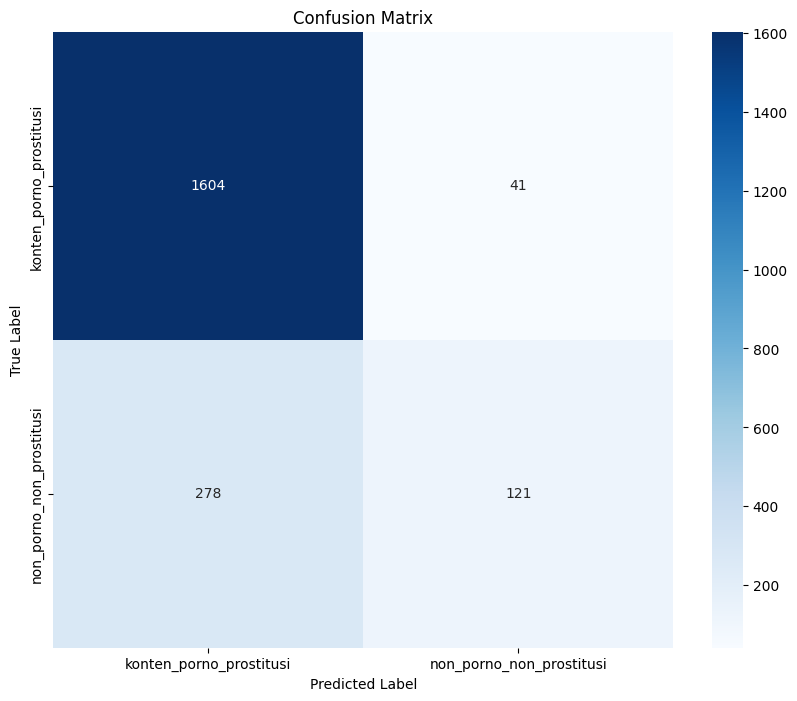

In [56]:
# === Evaluation ===
print("\n--- Evaluation Metrics ---")

y_true = []
y_pred = []

# Prepare data for scikit-learn evaluation
# We only evaluate items where a prediction could be made
for item in data:
    if item.get("postprocessed_answer") is not None and item.get("label") is not None:
        y_true.append(item["label"])
        y_pred.append(item["postprocessed_answer"])

total_evaluated = len(y_true)
if total_evaluated > 0:
    correct_predictions = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
    accuracy = correct_predictions / total_evaluated

    print(f"\nAccuracy (on cleanable data): {accuracy:.4f} ({correct_predictions}/{total_evaluated})")

    # Get all unique classes from both true and predicted labels for a complete report
    classes = sorted(list(set(y_true + y_pred)))
    print(f"Classes found for evaluation: {classes}")

    if not classes:
        print("No classes found to evaluate. Exiting.")
        exit()

    # --- Classification Report ---
    print("\nClassification Report:")
    # Set zero_division=0 to prevent errors if a class has no predictions
    report_str = classification_report(y_true, y_pred, labels=classes, zero_division=0)
    print(report_str)

    report_dict = classification_report(y_true, y_pred, labels=classes, output_dict=True, zero_division=0)

    # --- Detailed Metrics per Class ---
    for class_name in classes:
        if class_name in report_dict:
            print(f"\nMetrics for '{class_name}':")
            print(f"  Precision: {report_dict[class_name]['precision']:.4f}")
            print(f"  Recall:    {report_dict[class_name]['recall']:.4f}")
            print(f"  F1 Score:  {report_dict[class_name]['f1-score']:.4f}")

    # --- Overall Metrics ---
    print("\nOverall Metrics:")
    print(f"Accuracy:  {report_dict['accuracy']:.4f}")
    print(f"Macro F1:  {report_dict['macro avg']['f1-score']:.4f}")
    print(f"Weighted F1: {report_dict['weighted avg']['f1-score']:.4f}")

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    print("\nDisplaying Confusion Matrix plot...")
    plt.show()

else:
    print("\nNo items were cleanable for evaluation.")

# Post-Proccessing Zafran 

In [57]:
# Post processing baru agar few shot > zero shot pada SahabatAI
def regex_clean_original_answer(text):
  if "non_pornografi" in text.lower():
    return "non_pornografi"
  elif "pornografi" in text.lower():
    return "pornografi"
  else:
    return "non_pornografi"

def clean_original_answer(original_answer):
    """Maps the cleaned regex match to the final standardized labels."""
    match = regex_clean_original_answer(original_answer)
    if match:
        mapping = {
            "non_pornografi": "non_porno_non_prostitusi",
            "pornografi": "konten_porno_prostitusi"
        }
        return mapping.get(match)
    return "non_pornografi"

# NEW: Function to write the final data to a CSV file
def write_data_to_csv(data_list, csv_path):
    """Writes a list of dictionaries to a CSV file."""
    print(f"\nWriting consolidated data to CSV...")
    try:
        with open(csv_path, 'w', newline='', encoding='utf-8') as csv_file:
            # Define the headers for the CSV file
            writer = csv.writer(csv_file)
            writer.writerow(['text', 'original_answer', 'postprocessed_answer', 'label'])

            # Write each record from the data list
            for record in data_list:
                writer.writerow([
                    record.get('text', ''),
                    record.get('original_answer', ''),
                    record.get('postprocessed_answer', 'UNPROCESSABLE'), # Use a placeholder if not processed
                    record.get('label', '')
                ])
        print(f"Data successfully saved to {csv_path}")
    except IOError as e:
        print(f"Error writing to CSV file: {e}")

In [58]:
# ==== USER INPUTS & FILE DISCOVERY ====
# NEW: More flexible input handling for files or directories
input_path = f'/home/alvaro_luqman/resource/Inference Results/Prn/{llm_model}/{sim_function}/output_prn_{llm_model}_{sim_function}_few_bert_embed.jsonl'
processed_jsonl_path = f'/home/alvaro_luqman/resource/Inference Results/Prn/{llm_model}/{sim_function}/processed_prn_{llm_model}_{sim_function}_few_bert_embed.jsonl'
processed_csv_path = f'/home/alvaro_luqman/resource/Inference Results/Prn/{llm_model}/{sim_function}/processed_prn_{llm_model}_{sim_function}_few_bert_embed.csv' # NEW: Get path for CSV

# NEW: Logic to find all .jsonl files to process
jsonl_files_to_process = []
if os.path.isfile(input_path) and input_path.endswith('.jsonl'):
    jsonl_files_to_process.append(input_path)
elif os.path.isdir(input_path):
    print(f"Found directory. Searching for .jsonl files in {input_path}")
    # Sort the files for consistent processing order
    jsonl_files_to_process = sorted(list(Path(input_path).glob('*.jsonl')))
else:
    print(f"Error: Invalid input path. Not a valid file or directory.")
    exit(1)

if not jsonl_files_to_process:
    print(f"No .jsonl files found in the specified path.")
    exit(1)

print(f"\nFound {len(jsonl_files_to_process)} file(s) to process.")

# Initialize data and counters
data = []
processed_count = 0
missing_field_count = 0
error_count = 0
unmatchable_count = 0

# NEW: Loop through all discovered files
for file_path in jsonl_files_to_process:
    print(f"--- Processing file: {file_path} ---")
    try:
        with open(file_path, "r", encoding="utf-8") as file:
            for line_num, line in enumerate(file, 1):
                try:
                    obj = json.loads(line)

                    if "original_answer" not in obj or "label" not in obj:
                        missing_field_count += 1
                        continue

                    original_answer = obj.get("original_answer", "")
                    postprocessed = clean_original_answer(original_answer)

                    if postprocessed is not None:
                        obj["postprocessed_answer"] = postprocessed
                        processed_count += 1
                    else:
                        # NEW: Add a placeholder for evaluation and CSV consistency
                        obj["postprocessed_answer"] = None
                        unmatchable_count += 1
                        question = obj.get("text")
                        # This can be noisy, so you might want to comment it out for large files
                        # print(f"  Warning: No match found at line {line_num} in {file_path}\n    Answer: {original_answer}\n")

                    data.append(obj)

                except json.JSONDecodeError:
                    print(f"  Error: Could not parse JSON at line {line_num} in {file_path}")
                    error_count += 1
    except FileNotFoundError:
        print(f"Error: File not found during processing: {file_path}")
        continue

# Save postprocessed JSONL file
print("\n--- Saving Processed Files ---")
with open(processed_jsonl_path, "w", encoding="utf-8") as f_out:
    for item in data:
        json.dump(item, f_out, ensure_ascii=False)
        f_out.write("\n")
print(f"Processed JSONL data saved to {processed_jsonl_path}")

# NEW: Call the function to save the consolidated CSV file
write_data_to_csv(data, processed_csv_path)

print(f"\n--- Processing Summary ---")
print(f"Total records processed: {len(data)}")
print(f"Successfully cleaned: {processed_count}")
print(f"Could not find a match in 'original_answer': {unmatchable_count}")
print(f"Records with missing fields ('original_answer' or 'label'): {missing_field_count}")
print(f"JSON parsing errors: {error_count}")


Found 1 file(s) to process.
--- Processing file: /home/alvaro_luqman/resource/Inference Results/Prn/SahabatAI/dot/output_prn_SahabatAI_dot_few_bert_embed.jsonl ---

--- Saving Processed Files ---
Processed JSONL data saved to /home/alvaro_luqman/resource/Inference Results/Prn/SahabatAI/dot/processed_prn_SahabatAI_dot_few_bert_embed.jsonl

Writing consolidated data to CSV...
Data successfully saved to /home/alvaro_luqman/resource/Inference Results/Prn/SahabatAI/dot/processed_prn_SahabatAI_dot_few_bert_embed.csv

--- Processing Summary ---
Total records processed: 2044
Successfully cleaned: 2044
Could not find a match in 'original_answer': 0
Records with missing fields ('original_answer' or 'label'): 0
JSON parsing errors: 0



--- Evaluation Metrics ---

Accuracy (on cleanable data): 0.8454 (1728/2044)
Classes found for evaluation: ['konten_porno_prostitusi', 'non_porno_non_prostitusi']

Classification Report:
                          precision    recall  f1-score   support

 konten_porno_prostitusi       0.88      0.94      0.91      1645
non_porno_non_prostitusi       0.65      0.45      0.53       399

                accuracy                           0.85      2044
               macro avg       0.76      0.70      0.72      2044
            weighted avg       0.83      0.85      0.83      2044


Metrics for 'konten_porno_prostitusi':
  Precision: 0.8761
  Recall:    0.9410
  F1 Score:  0.9074

Metrics for 'non_porno_non_prostitusi':
  Precision: 0.6498
  Recall:    0.4511
  F1 Score:  0.5325

Overall Metrics:
Accuracy:  0.8454
Macro F1:  0.7200
Weighted F1: 0.8342

Displaying Confusion Matrix plot...


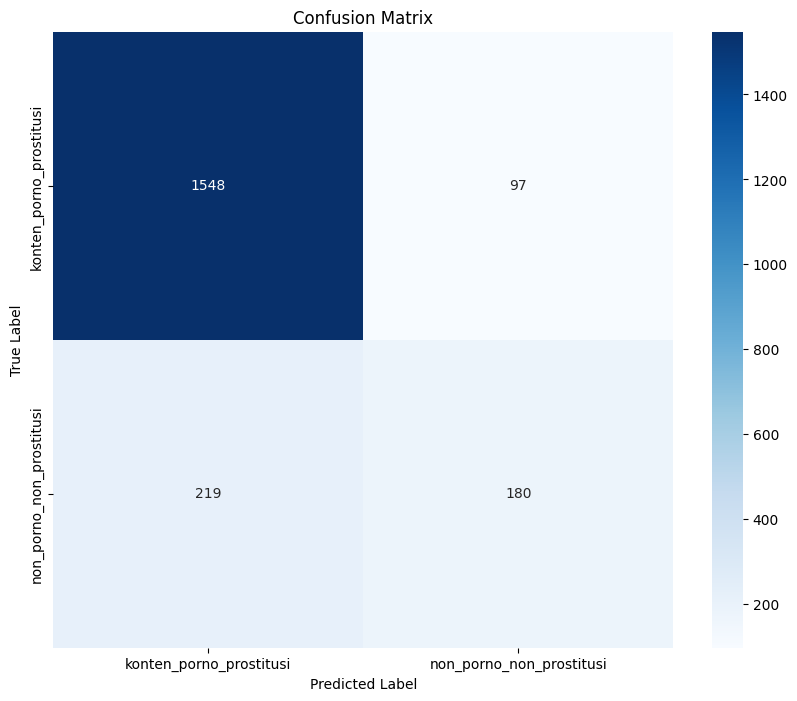

In [59]:
# === Evaluation ===
print("\n--- Evaluation Metrics ---")

y_true = []
y_pred = []

# Prepare data for scikit-learn evaluation
# We only evaluate items where a prediction could be made
for item in data:
    if item.get("postprocessed_answer") is not None and item.get("label") is not None:
        y_true.append(item["label"])
        y_pred.append(item["postprocessed_answer"])

total_evaluated = len(y_true)
if total_evaluated > 0:
    correct_predictions = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
    accuracy = correct_predictions / total_evaluated

    print(f"\nAccuracy (on cleanable data): {accuracy:.4f} ({correct_predictions}/{total_evaluated})")

    # Get all unique classes from both true and predicted labels for a complete report
    classes = sorted(list(set(y_true + y_pred)))
    print(f"Classes found for evaluation: {classes}")

    if not classes:
        print("No classes found to evaluate. Exiting.")
        exit()

    # --- Classification Report ---
    print("\nClassification Report:")
    # Set zero_division=0 to prevent errors if a class has no predictions
    report_str = classification_report(y_true, y_pred, labels=classes, zero_division=0)
    print(report_str)

    report_dict = classification_report(y_true, y_pred, labels=classes, output_dict=True, zero_division=0)

    # --- Detailed Metrics per Class ---
    for class_name in classes:
        if class_name in report_dict:
            print(f"\nMetrics for '{class_name}':")
            print(f"  Precision: {report_dict[class_name]['precision']:.4f}")
            print(f"  Recall:    {report_dict[class_name]['recall']:.4f}")
            print(f"  F1 Score:  {report_dict[class_name]['f1-score']:.4f}")

    # --- Overall Metrics ---
    print("\nOverall Metrics:")
    print(f"Accuracy:  {report_dict['accuracy']:.4f}")
    print(f"Macro F1:  {report_dict['macro avg']['f1-score']:.4f}")
    print(f"Weighted F1: {report_dict['weighted avg']['f1-score']:.4f}")

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    print("\nDisplaying Confusion Matrix plot...")
    plt.show()

else:
    print("\nNo items were cleanable for evaluation.")

In [60]:
import nbformat
import os

current_notebook = '/home/alvaro_luqman/resource/Scripts/Prn/new_porn_content_analysis_w_indobert_classification_deepseek.ipynb'  

notebook_output_path = f'/home/alvaro_luqman/resource/Inference Results/Prn/{llm_model}/{sim_function}/new_porn_content_analysis_w_indobert_classification_{llm_model}_{sim_function}.ipynb'

# Create directories
os.makedirs(os.path.dirname(notebook_output_path), exist_ok=True)

# Read current notebook with outputs
with open(current_notebook, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

# Save to new location
with open(notebook_output_path, 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)

print(f"Saved to: {notebook_output_path}")

Saved to: /home/alvaro_luqman/resource/Inference Results/Prn/SahabatAI/dot/new_porn_content_analysis_w_indobert_classification_SahabatAI_dot.ipynb
